In [ ]:
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from process_and_merge_files import process_and_merge_files
from pathlib import Path

# Use absolute path
base_path = Path("/Users/aa13586/Desktop/symmetric-dirichlet")

# 1. Define the list of files to process
# This grabs all csv files matching the pattern in the current directory
files_to_process = glob.glob(str(base_path / "output/test13_s/statistics/tables/comparison_p=*_err=*.csv"))

# Alternatively, if you want to specify the list manually based on your upload:
# files_to_process = [
#     "comparison_p=1_err=0.01.csv",
#     "comparison_p=1_err=0.001.csv",
#     "comparison_p=1_err=0.05.csv",
#     "comparison_p=3_err=0.01.csv",
#     "comparison_p=3_err=0.001.csv",
#     "comparison_p=3_err=0.05.csv",
#     "comparison_p=5_err=0.01.csv",
#     "comparison_p=5_err=0.001.csv",
#     "comparison_p=5_err=0.05.csv"
# ]

# 2. Call the function
folder = base_path / "output/test13_s/statistics/tables"
df_melted = process_and_merge_files(files_to_process, output_dir=folder)

# 3. Inspect the result
print(df_melted.head())

No data found.
Empty DataFrame
Columns: []
Index: []


In [3]:
print(df_melted['total_time'])

0      16.3880
1      24.1877
2      12.4771
3       5.1014
4      38.3374
        ...   
611     3.1711
612    10.9884
613     7.4299
614    11.3942
615    14.5315
Name: total_time, Length: 616, dtype: float64


Meshes: ['isidore_horse_param' 'brain100k_param' 'thai_statue_param'
 'pensatore_param' 'vase-lion100K_param' 'torso_param' 'buste_param'
 'vase100K_param' 'armchair_param' 'filigree100k_param'
 'dragonstand_recon100K_param' 'oil_pump100K_param' 'gearbox_param'
 'carter100K_param' 'master_cylinder100K_param' 'sediapatch1_100K_param'
 'seahorse2_100K_param' 'lucy100k_param' 'magalie_hand100K_param'
 'heptoroid100k_param' 'gargoyle100K_param' 'knot100K_param'
 'neptune0_param' 'kitten100K_param' 'chair_param' 'uu-memento100k_param'
 'botijo_param' 'camille_hand100K_param' 'ramses_param'
 'dancing_children100K_param' 'pierrot100k_param' 'bimba100K_param'
 'chair100K_param' 'bunnyBotsch_param' 'pulley100K_param' 'santa_param'
 'vh_skin_param' 'eros100K_param' 'rolling_stage100K_param'
 'igea100k_param' 'deformed_armadillo_param' 'red_circular_box100K_param'
 'bozbezbozzel100K_param' 'rgb_dragon_param']
Solvers: ['CG', 'Ch_LLT']
Errors: [np.float64(0.05)]
Thresholds: [0.25, 0.5, 0.75, 1.0, 

NameError: name 'np' is not defined

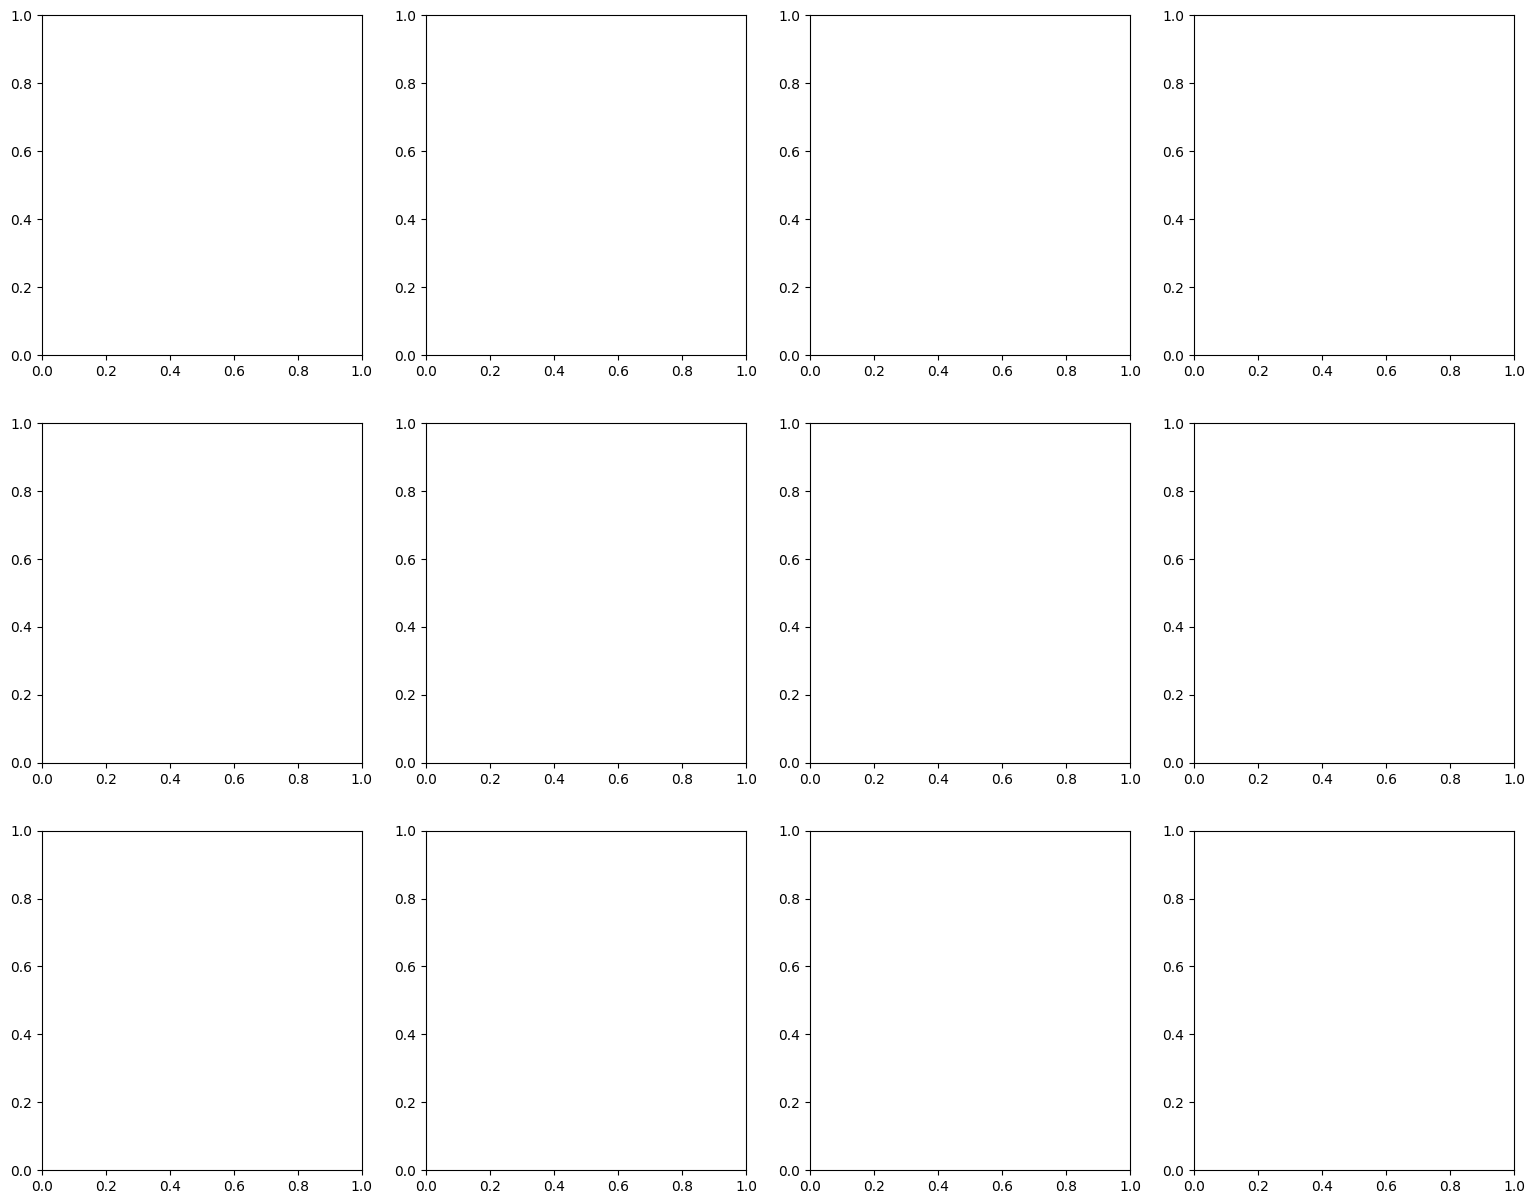

In [4]:
import os
from pathlib import Path

# Create output directories
output_base = Path("output/analysis_plots")
combined_dir = output_base / "combined_meshes"

# Get unique meshes, solvers, and thresholds
meshes = df_melted['Mesh'].unique()
solvers = sorted(df_melted['solver_type'].unique())
errors = sorted(df_melted['err'].unique())

# Extract threshold values from column names
threshold_cols = [col for col in df_melted.columns if col.startswith('E>=')]
thresholds = sorted([float(col.replace('E>=', '')) for col in threshold_cols])

print(f"Meshes: {meshes}")
print(f"Solvers: {solvers}")
print(f"Errors: {errors}")
print(f"Thresholds: {thresholds}")

# For each solver
for solver in solvers:
    solver_dir = combined_dir / solver
    solver_dir.mkdir(parents=True, exist_ok=True)
    
    # For each error tolerance
    for err in errors:
        # Create figure with subplots (one per threshold)
        fig, axes = plt.subplots(3, len(thresholds) // 3 + 1, figsize=(5*len(thresholds) // 3 + 3, 15))
        if len(thresholds) == 1:
            axes = [axes]
        
        # Flatten axes for easier iteration
        axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]
        
        fig.suptitle(f"{solver} - err={err} - All Meshes", fontsize=16, fontweight='bold')
        
        # Collect all lines and labels for shared legend
        all_lines = []
        all_labels = []
        
        # Plot for each threshold
        for idx, threshold in enumerate(thresholds):
            ax = axes[idx]
            col_name = f'E>={threshold}'
            
            # Filter data for this solver and error
            mask = (df_melted['solver_type'] == solver) & (df_melted['err'] == err)
            data_subset = df_melted[mask]
            
            if col_name in data_subset.columns:
                # Plot each mesh as a different line
                for mesh in meshes:
                    mesh_mask = (data_subset['Mesh'] == mesh)
                    mesh_data = data_subset[mesh_mask][['p', col_name]].sort_values('p')
                    
                    if not mesh_data.empty:
                        line, = ax.plot(mesh_data['p'], mesh_data[col_name], marker='o', markersize=4, label=mesh, linewidth=2, alpha=0.6)
                        # Collect line and label only once (from first subplot)
                        if idx == 0:
                            all_lines.append(line)
                            all_labels.append(mesh)
            
            ax.set_xlabel('p (percentage)', fontsize=12)
            ax.set_ylabel(f'count%(|E>={threshold}|/ |F|)', fontsize=12)
            ax.set_title(f'E>={threshold}', fontsize=13, fontweight='bold')
            ax.grid(True, alpha=0.3, which='both')
        
        # Hide empty subplots
        for idx in range(len(thresholds), len(axes)):
            axes[idx].set_visible(False)
        
        # Create shared legend outside the plots
        if all_lines:
            fig.legend(all_lines, all_labels, loc='center right', 
                      bbox_to_anchor=(1.15, 0.5), fontsize=10, frameon=True)
        
        plt.tight_layout()
        
        # Save
        output_path = solver_dir / f"err={err}_all_thresholds.png"
        fig.savefig(str(output_path), dpi=150, bbox_inches='tight')
        plt.close(fig)
        
        print(f"Saved: {output_path}")

print(f"\nAll figures saved to: {combined_dir}")

In [5]:
import os
from pathlib import Path
import numpy as np
# Create output directories
output_base = Path("output/analysis_plots")
time_dir = output_base / "total_time"
time_dir.mkdir(parents=True, exist_ok=True)

# Get unique meshes and solvers
meshes = df_melted['Mesh'].unique()
solvers = sorted(df_melted['solver_type'].unique())
errors = sorted(df_melted['err'].unique())

print(f"Meshes: {meshes}")
print(f"Solvers: {solvers}")
print(f"Errors: {errors}")

# Color for each mesh
num_meshes = len(meshes)
colors_mesh = plt.cm.hsv(np.linspace(0, 0.95, num_meshes))
mesh_colors = {mesh: colors_mesh[i] for i, mesh in enumerate(meshes)}
max_time = df_melted['total_time'].max()
# For each solver
for solver in solvers:
    # Create figure with 1 row and 3 columns (one per error)
    fig, axes = plt.subplots(1, len(errors), figsize=(5*len(errors) + 3, 6))
    if len(errors) == 1:
        axes = [axes]
    
    fig.suptitle(f"{solver} - Total Time - All Meshes", fontsize=16, fontweight='bold')
    
    # Collect all lines and labels for shared legend
    all_lines = []
    all_labels = []
    
    # Plot for each error tolerance
    for err_idx, err in enumerate(errors):
        ax = axes[err_idx]
        
        # Plot each mesh
        for mesh in meshes:
            # Filter data for this mesh, solver, and error
            mask = (df_melted['Mesh'] == mesh) & (df_melted['solver_type'] == solver) & (df_melted['err'] == err)
            data_subset = df_melted[mask]
            
            if 'total_time' in data_subset.columns and not data_subset.empty:
                time_data = data_subset[['p', 'total_time']].sort_values('p')
                print(time_data)
                if not time_data.empty:
                    line, = ax.plot(time_data['p'], time_data['total_time'], 
                                   marker='o', label=mesh, linewidth=2, 
                                   color=mesh_colors[mesh])
                    # Collect line and label only once (from first subplot)
                    if err_idx == 0:
                        all_lines.append(line)
                        all_labels.append(mesh)
        
        ax.set_xlabel('p (percentage)', fontsize=12)
        ax.set_ylabel('Total Time (seconds)', fontsize=12)
        ax.set_title(f'err={err}', fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3)
    
    # Create shared legend outside the plots
    fig.legend(all_lines, all_labels, loc='center right', 
              bbox_to_anchor=(1.5, 0.5), fontsize=10, frameon=True)
    
    plt.tight_layout()
    
    # Save
    output_path = time_dir / f"{solver}_total_time_all_meshes.png"
    fig.savefig(str(output_path), dpi=150, bbox_inches='tight')
    plt.close(fig)
    
    print(f"Saved: {output_path}")

print(f"\nAll figures saved to: {time_dir}")

Meshes: ['isidore_horse_param' 'brain100k_param' 'thai_statue_param'
 'pensatore_param' 'vase-lion100K_param' 'torso_param' 'buste_param'
 'vase100K_param' 'armchair_param' 'filigree100k_param'
 'dragonstand_recon100K_param' 'oil_pump100K_param' 'gearbox_param'
 'carter100K_param' 'master_cylinder100K_param' 'sediapatch1_100K_param'
 'seahorse2_100K_param' 'lucy100k_param' 'magalie_hand100K_param'
 'heptoroid100k_param' 'gargoyle100K_param' 'knot100K_param'
 'neptune0_param' 'kitten100K_param' 'chair_param' 'uu-memento100k_param'
 'botijo_param' 'camille_hand100K_param' 'ramses_param'
 'dancing_children100K_param' 'pierrot100k_param' 'bimba100K_param'
 'chair100K_param' 'bunnyBotsch_param' 'pulley100K_param' 'santa_param'
 'vh_skin_param' 'eros100K_param' 'rolling_stage100K_param'
 'igea100k_param' 'deformed_armadillo_param' 'red_circular_box100K_param'
 'bozbezbozzel100K_param' 'rgb_dragon_param']
Solvers: ['CG', 'Ch_LLT']
Errors: [np.float64(0.05)]
       p  total_time
440  1.0     2

In [20]:
# Count convergences by solver and p
convergence_counts = []

for solver in sorted(df_melted['solver_type'].unique()):
    print(f"\n{'='*60}")
    print(f"SOLVER: {solver}")
    print(f"{'='*60}")
    print(f"{'p':<10} {'Converged':<15} {'Total Meshes':<15}")
    print(f"{'-'*60}")
    
    for p in sorted(df_melted['p'].unique()):
        # Total unique meshes for this solver and p
        total_meshes = len(df_melted[
            (df_melted['solver_type'] == solver) & 
            (df_melted['p'] == p)
        ]['Mesh'].unique())
        
        # Converged meshes for this solver and p
        converged_meshes = len(df_melted[
            (df_melted['solver_type'] == solver) & 
            (df_melted['p'] == p) &
            (df_melted['converge_reason'] == "Energy reached 1.0")
        ]['Mesh'].unique())
        
        print(f"{p:<10.1f} {converged_meshes:<15} {total_meshes:<15}")
        
        convergence_counts.append({
            'Solver': solver,
            'p': p,
            'Converged_Meshes': converged_meshes,
            'Total_Meshes': total_meshes
        })

# Create summary DataFrame
convergence_summary_df = pd.DataFrame(convergence_counts)

print(f"\n{'='*60}")
print("SUMMARY TABLE")
print(f"{'='*60}\n")
print(convergence_summary_df.to_string(index=False))

# Save to CSV
convergence_summary_df.to_csv("convergence_by_solver_and_p.csv", index=False)
print(f"\n✓ Saved to: convergence_by_solver_and_p.csv")


SOLVER: CG
p          Converged       Total Meshes   
------------------------------------------------------------
1.0        36              44             
3.0        36              44             
5.0        35              44             

SOLVER: Ch_LLT
p          Converged       Total Meshes   
------------------------------------------------------------
1.0        43              44             
3.0        43              44             
5.0        43              44             

SUMMARY TABLE

Solver   p  Converged_Meshes  Total_Meshes
    CG 1.0                36            44
    CG 3.0                36            44
    CG 5.0                35            44
Ch_LLT 1.0                43            44
Ch_LLT 3.0                43            44
Ch_LLT 5.0                43            44

✓ Saved to: convergence_by_solver_and_p.csv


In [1]:
import sys
import subprocess

print(f"Python executable: {sys.executable}")
print(f"Python version: {sys.version}")
print("\nInstalled packages:")
result = subprocess.run([sys.executable, "-m", "pip", "list"], capture_output=True, text=True)
print(result.stdout)

Python executable: /Users/aa13586/Desktop/symmetric-dirichlet/py_codes/venv/bin/python
Python version: 3.9.6 (default, Dec  2 2025, 07:27:58) 
[Clang 17.0.0 (clang-1700.6.3.2)]

Installed packages:
Package             Version
------------------- -----------
appnope             0.1.4
asttokens           3.0.1
comm                0.2.3
contourpy           1.3.0
cycler              0.12.1
debugpy             1.8.19
decorator           5.2.1
exceptiongroup      1.3.1
executing           2.2.1
fonttools           4.60.1
importlib_metadata  8.7.1
importlib_resources 6.5.2
ipykernel           6.31.0
ipython             8.18.1
jedi                0.19.2
jupyter_client      8.6.3
jupyter_core        5.8.1
kiwisolver          1.4.7
libigl              2.6.1
matplotlib          3.9.4
matplotlib-inline   0.2.1
nest-asyncio        1.6.0
numpy               2.0.2
packaging           25.0
pandas              2.3.3
parso               0.8.5
pexpect             4.9.0
pillow              11.3.0
pip     

In [2]:
import polyscope as ps
from pathlib import Path

# Base path
base_path = Path("/Users/aa13586/Desktop/symmetric-dirichlet")
test11_path = base_path / "output" / "test11"

# Create output directory for snapshots
snapshot_dir = base_path / "output" / "mesh_snapshots"
snapshot_dir.mkdir(parents=True, exist_ok=True)

# Initialize polyscope
ps.init()
ps.set_ground_plane_mode("shadow")

# Go through each folder in test11
for folder in sorted(test11_path.iterdir()):
    if not folder.is_dir():
        continue
    
    print(f"\nProcessing: {folder.name}")
    
    # Look for OBJ files
    obj_files = list(folder.rglob("*.obj"))
    
    if not obj_files:
        print(f"  No OBJ files found")
        continue
    
    # Process first OBJ file
    obj_file = obj_files[0]
    print(f"  Loading: {obj_file.relative_to(folder)}")
    
    try:
        ps.remove_all_structures()
        # Load mesh from OBJ file
        ps.load_surface_mesh(str(obj_file), folder.name)
        
        # Configure view
        ps.look_at((0, 0, 2), (0, 0, 0))
        
        # Save screenshot
        snapshot_path = snapshot_dir / f"{folder.name}.png"
        ps.screenshot(str(snapshot_path), transparent_bg=False)
        print(f"  ✓ Saved snapshot: {snapshot_path.name}")
    
    except Exception as e:
        print(f"  Error processing {obj_file.name}: {e}")

ps.shutdown()
print(f"\n{'='*80}")
print(f"All snapshots saved to: {snapshot_dir}")
print(f"{'='*80}")

ModuleNotFoundError: No module named 'polyscope'